In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from typing import TypedDict,Annotated
from pydantic import BaseModel,Field
import operator

In [2]:
class EvaluationSchema(BaseModel):

    feedback:str = Field(description="Detailed Feedback for the essay")
    score:int = Field(description="Score out of 10",ge=0,le=10)

In [3]:
llm = ChatOllama(model="llama3.2:3b", temperature=0.1,format="json")
structured_model = llm.with_structured_output(EvaluationSchema) 

In [4]:
class UPSCState(TypedDict):

    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    # adding the scores from different nodes that we are looking for average
    individual_scores:Annotated[list[int],operator.add]
    avg_score:float


In [5]:
def Evaluate_Language(state: UPSCState) -> UPSCState:

    prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \m {state['essay']}"
    output = structured_model.invoke(prompt)

    return {"language_feedback": output.feedback, "individual_scores": [output.score]}


def Evaluate_Analysis(state: UPSCState) -> UPSCState:

    prompt = f"Evaluate the Depth Analysis of the following essay and provide a feedback and assign a score out of 10 \m {state['essay']}"
    output = structured_model.invoke(prompt)

    return {"analysis_feedback": output.feedback, "individual_scores": [output.score]}


def Evaluate_Thought(state: UPSCState) -> UPSCState:

    prompt = f"Evaluate the Clarity of thought of the following essay and provide a feedback and assign a score out of 10 \m {state['essay']}"
    output = structured_model.invoke(prompt)

    return {"clarity_feedback": output.feedback, "individual_scores": [output.score]}


def Final_Evaluation(state: UPSCState) -> UPSCState:

    prompt = f"Based on the Following feedbacks create a summarized feedback \n language feedback -{state['language_feedback']}\n depth of analysis feedback - {state['analysis_feedback']} \n clarity of feedback -{state['clarity_feedback']}"
    overall_feedback = llm.invoke(prompt).content

    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])

    return {"overall_feedback":overall_feedback,"avg_score":avg_score}

In [6]:
graph = StateGraph(UPSCState)

graph.add_node("Evaluate_Language",Evaluate_Language)
graph.add_node("Evaluate_Analysis",Evaluate_Analysis)
graph.add_node("Evaluate_Thought",Evaluate_Thought)
graph.add_node("Final_Evaluation",Final_Evaluation)

graph.add_edge(START,"Evaluate_Language")
graph.add_edge(START,"Evaluate_Analysis")
graph.add_edge(START,"Evaluate_Thought")

graph.add_edge("Evaluate_Language","Final_Evaluation")
graph.add_edge("Evaluate_Analysis","Final_Evaluation")
graph.add_edge("Evaluate_Thought","Final_Evaluation")

graph.add_edge("Final_Evaluation",END)

workflow = graph.compile()

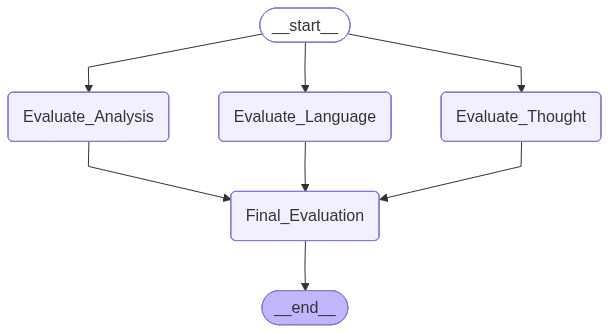

In [7]:
workflow

In [ ]:
essay = """Technology: A Double-Edged Sword Shaping Human Destiny
From the discovery of fire to the rise of artificial intelligence, technology has been the most powerful force shaping human civilization. It has acted both as an enabler of progress and as a disruptor of social, ethical, and ecological balance. In the 21st century, technology is no longer merely a tool; it has become a determinant of economic power, governance capability, social relationships, and even human identity. Thus, technology is best understood not as an unqualified blessing or curse, but as a double-edged sword whose impact depends on human values, institutions, and wisdom.
Technology as an Engine of Human Progress
Historically, technological advancement has been synonymous with civilizational growth. The agricultural revolution ensured food security, the industrial revolution increased productivity, and the digital revolution democratized information. In contemporary times, technology has dramatically improved the quality of life, enhanced life expectancy, and expanded human capabilities.
In healthcare, advances such as telemedicine, robotic surgery, genomics, and AI-based diagnostics have made medical services more accessible and precise. During the COVID-19 pandemic, digital platforms, vaccine technology, and data analytics played a decisive role in saving lives.
In education, technology has broken geographical barriers. Online learning platforms, digital classrooms, and open educational resources have enabled learning beyond traditional institutions. For a diverse country like India, initiatives such as Digital India, SWAYAM, and DIKSHA have strengthened inclusive education.
Economically, technology has been a catalyst for growth and innovation. Start-ups, fintech, e-commerce, and digital payments have transformed markets. India’s Unified Payments Interface (UPI) is a global example of how technology can promote financial inclusion while reducing transaction costs.
Technology and Governance: Towards a Digital State
Technology has redefined governance by enhancing efficiency, transparency, and accountability. E-governance initiatives such as Aadhaar, Direct Benefit Transfer (DBT), and online public service delivery have reduced leakages and corruption. Data-driven decision-making enables evidence-based policy formulation, improving state capacity.
Moreover, technology strengthens democratic participation through social media, digital campaigns, and grievance redressal platforms. It allows citizens to engage directly with the state, thereby deepening democracy.
However, this digital transformation also raises concerns about data privacy, surveillance, and algorithmic bias. Without strong legal and ethical frameworks, technology may weaken civil liberties instead of strengthening democracy.
The Social and Ethical Challenges of Technology
Despite its benefits, technology has also introduced serious social challenges. One of the most pressing issues is the digital divide. Unequal access to technology based on income, gender, region, and education risks creating a new form of inequality—digital exclusion. In India, rural-urban and gender gaps in internet access remain significant.
Automation and artificial intelligence, while increasing efficiency, threaten traditional employment. Job displacement, skill obsolescence, and informalization of work pose challenges to social stability. The future of work demands not only technological skills but also adaptive education systems and social security mechanisms.
Ethically, emerging technologies such as AI, biotechnology, and surveillance tools raise profound questions about human autonomy, privacy, and moral responsibility. The use of facial recognition, deepfakes, and predictive algorithms can lead to misuse, misinformation, and social manipulation. Technology, when divorced from ethics, risks dehumanizing society.
Technology and Environment: Boon or Bane?
Technology’s relationship with the environment is deeply paradoxical. On one hand, industrial and technological expansion has contributed to climate change, pollution, and resource depletion. On the other hand, technology offers solutions through renewable energy, green innovation, climate modeling, and sustainable agriculture.
Technologies such as solar and wind energy, electric vehicles, and smart grids are essential for achieving sustainable development goals. Precision farming, biotechnology, and satellite monitoring help in conserving resources and ensuring food security.
The challenge lies in adopting a development model where technology serves ecological balance rather than exploiting nature. Sustainable technology must be guided by the principle of intergenerational equity.
Technology and Human Values: The Way Forward
The ultimate question is not what technology can do, but what it should do. Technology is value-neutral; its outcomes are shaped by human intent, governance, and ethical frameworks. As Mahatma Gandhi warned, “Science without humanity” can become destructive.
To harness technology for inclusive and sustainable development, societies must focus on:
Ethical governance of technology
Inclusive digital access
Skill-oriented and value-based education
Strong regulatory institutions
Human-centric innovation
India, with its demographic dividend and digital ambition, has the opportunity to chart a middle path—combining technological advancement with constitutional values of justice, liberty, equality, and fraternity.
Conclusion
Technology is neither a panacea nor a peril in itself; it is a powerful instrument reflecting human choices. Used wisely, it can eliminate poverty, empower citizens, strengthen democracy, and protect the planet. Used recklessly, it can deepen inequality, erode freedoms, and destabilize societies. The real challenge before humanity is to ensure that technology remains a servant of human welfare, not its master. In this balance between innovation and ethics lies the future of civilization."""

In [56]:
initial_state={
    'essay':essay
}
final_state = workflow.invoke(initial_state)

print(final_state)

{'essay': 'Technology: A Double-Edged Sword Shaping Human Destiny\n\nFrom the discovery of fire to the rise of artificial intelligence, technology has been the most powerful force shaping human civilization. It has acted both as an enabler of progress and as a disruptor of social, ethical, and ecological balance. In the 21st century, technology is no longer merely a tool; it has become a determinant of economic power, governance capability, social relationships, and even human identity. Thus, technology is best understood not as an unqualified blessing or curse, but as a double-edged sword whose impact depends on human values, institutions, and wisdom.\n\nTechnology as an Engine of Human Progress\n\nHistorically, technological advancement has been synonymous with civilizational growth. The agricultural revolution ensured food security, the industrial revolution increased productivity, and the digital revolution democratized information. In contemporary times, technology has dramaticall

In [ ]:
print(final_state['language_feedback'])
print(final_state['analysis_feedback'])
print(final_state['clsarity_feedback'])
print(final_state['overall_feedback'])
print(final_state['avg_score'])

The essay provides a comprehensive analysis of the impact of technology on human society, highlighting both its benefits and drawbacks. The language is formal and academic, with proper citations and references to support arguments. However, there are areas for improvement in terms of clarity, coherence, and engagement.
The essay provides a comprehensive analysis of the impact of technology on human society, highlighting both its benefits and drawbacks. The author presents a nuanced view of technology as a double-edged sword that can be used for good or ill, depending on human values and institutions. The essay is well-structured, with clear sections and logical transitions between ideas. However, some points could be further developed and supported with more evidence and examples.
The essay provides a comprehensive analysis of the impact of technology on human society, highlighting both its benefits and drawbacks. The writer effectively explores various aspects of technology, including